vlm=2: entries = 65854.0
vlm=3: entries = 133715.0
vlm=4: entries = 49960.0
vlm=5: entries = 33.0
vlm=6: entries = 0.0
vlm=7: entries = 0.0


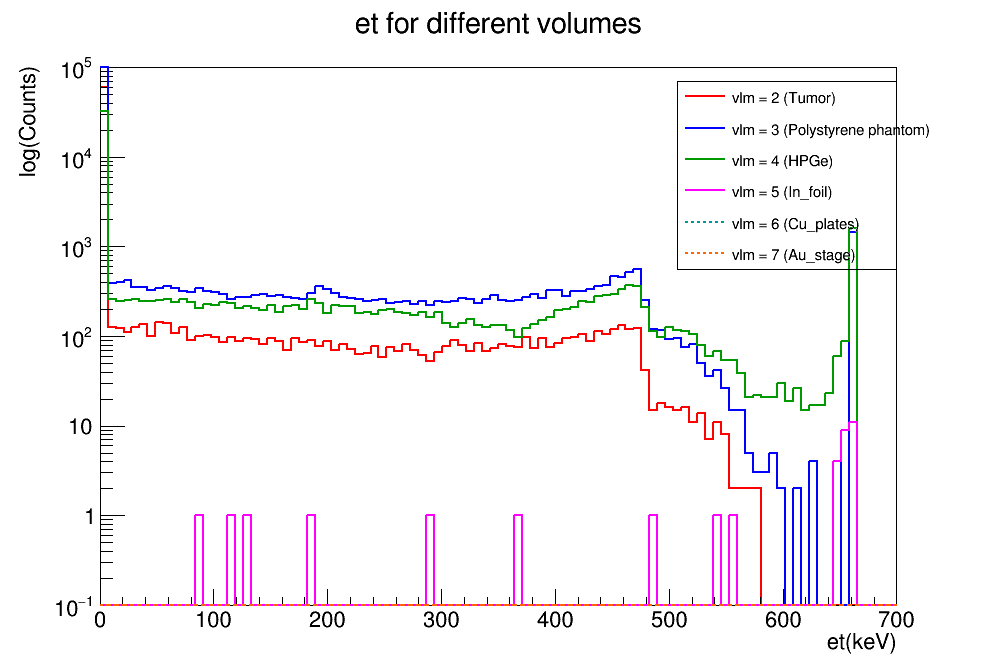

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file et_vlm_plot.png has been created


In [5]:
import ROOT
from IPython.display import Image, display

%jsroot on

f = ROOT.TFile.Open("sucrose.root")
t = f.Get("t")

c = ROOT.TCanvas("c", "et for different volumes", 1000, 700)
c.cd()
c.SetLogy()

legend = ROOT.TLegend(0.68, 0.60, 0.90, 0.88)
legend.SetBorderSize(1)
legend.SetFillStyle(0)
legend.SetTextSize(0.025)

colors = [
    ROOT.kRed, ROOT.kBlue, ROOT.kGreen+2, ROOT.kMagenta,
    ROOT.kCyan+2, ROOT.kOrange+7, ROOT.kBlack,
    ROOT.kViolet, ROOT.kTeal+2, ROOT.kPink+7
]

names = {
   
    2: "Tumor",
    3: "Polystyrene phantom",
    4: "HPGe",
    5: "In_foil",
    6: "Cu_plates",
    7: "Au_stage"
}

hist_list = []
first = True

for i, vlm in enumerate(range(2, 8)):
    hname = f"h_vlm_{vlm}"

    old = ROOT.gROOT.FindObject(hname)
    if old:
        old.Delete()

    h = ROOT.TH1F(hname, "et for different volumes;et(keV);log(Counts)", 100, 0, 700)
    t.Draw(f"et>>{hname}", f"vlm=={vlm}", "goff")

    print(f"vlm={vlm}: entries =", h.GetEntries())

    h.SetLineColor(colors[i % len(colors)])
    h.SetLineWidth(2)
    h.SetStats(0)

    if h.GetEntries() == 0:
        h.SetLineStyle(2)
        h.SetBinContent(1, 0.1)   # so empty volumes appear on log scale

    if first:
        h.SetMinimum(0.1)
        h.SetMaximum(1e5)
        h.Draw("hist")
        first = False
    else:
        h.Draw("hist same")

    # keep this INSIDE the loop
    label = f"vlm = {vlm}"
    if vlm in names:
        label += f" ({names[vlm]})"

    legend.AddEntry(h, label, "l")
    hist_list.append(h)

legend.Draw()
c.Modified()
c.Update()

c.SaveAs("et_vlm_plot.png")
display(Image(filename="et_vlm_plot.png"))